# Logistic Regression 

Modeling using testing/training data, addressing oversampling using SMOTEEN

## Importing Packages

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Loading Data

In [4]:
thyroid_train_labels = pd.read_csv("thyroid_train_labels.csv")
thyroid_train_labels

,0
0,0
1,0
2,0
3,0
4,0
...,...
7328,1
7329,0
7330,0
7331,0


In [5]:
thyroid_train = pd.read_csv("thyroid_train.csv")
thyroid_train

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
0,45,0,108.442729,1.931772,0.956728,1.204034,103.290203,0,0,0,...,0,0,0,0,1,1,1,1,1,0
1,23,0,109.690971,1.700000,0.964004,0.800000,107.000000,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,71,1,107.000000,1.700000,1.060000,2.700000,113.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,46,0,136.000000,1.917229,0.860000,0.060000,117.000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,83,0,160.000000,1.775536,0.920000,1.800000,147.000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,77,0,81.000000,1.614555,1.020000,36.000000,82.000000,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7329,64,0,108.000000,1.776734,0.920000,1.400000,99.000000,0,0,0,...,1,0,0,0,0,1,0,0,0,0
7330,24,1,106.000000,1.700000,1.000000,1.300000,106.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7331,62,0,93.000000,1.900000,0.710000,1.600000,66.000000,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
thyroid_test = pd.read_csv("thyroid_test.csv")
thyroid_test

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
0,23,0,120.0,2.300000,1.25,3.70,150.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,40,1,90.0,2.300000,0.96,1.30,87.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,22,1,80.0,2.300000,1.01,2.10,81.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34,0,101.0,1.800000,0.97,0.73,97.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,79,0,100.0,1.300000,0.92,2.40,92.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,68,0,93.0,1.896305,1.02,1.20,95.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1830,87,0,147.0,1.700000,0.96,2.50,140.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1831,57,1,256.0,3.700000,0.95,0.05,244.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1832,50,0,103.0,2.500000,1.11,1.80,114.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
thyroid_test_labels = pd.read_csv("thyroid_test_labels.csv")
thyroid_test_labels

,0
0,0
1,0
2,0
3,0
4,0
...,...
1829,0
1830,0
1831,2
1832,0


## Setting up X and Y

In [8]:
X_train = thyroid_train
X_train.columns

Index(['age', 'sex', 'FTI', 'T3', 'T4U', 'TSH', 'TT4', 'I131 treatment',
       'goitre', 'hypopituitary', 'lithium', 'on antithyroid medication',
       'on thyroxine', 'pregnant', 'psych', 'query hyperthyroid',
       'query hypothyroid', 'query on thyroxine', 'sick', 'thyroid surgery',
       'tumor', 'FTI_missing', 'T3_missing', 'T4U_missing', 'TSH_missing',
       'TT4_missing', 'sex_missing'],
      dtype='object')

In [9]:
y_train = thyroid_train_labels
y_train.shape

(7333, 1)

In [10]:
X_test = thyroid_test
X_test.columns

Index(['age', 'sex', 'FTI', 'T3', 'T4U', 'TSH', 'TT4', 'I131 treatment',
       'goitre', 'hypopituitary', 'lithium', 'on antithyroid medication',
       'on thyroxine', 'pregnant', 'psych', 'query hyperthyroid',
       'query hypothyroid', 'query on thyroxine', 'sick', 'thyroid surgery',
       'tumor', 'FTI_missing', 'T3_missing', 'T4U_missing', 'TSH_missing',
       'TT4_missing', 'sex_missing'],
      dtype='object')

In [11]:
y_test = thyroid_test_labels
y_test.shape

(1834, 1)

In [12]:
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

y_train distribution:
 0
0    6713
1     474
2     146
Name: count, dtype: int64
y_test distribution:
 0
0    1679
1     119
2      36
Name: count, dtype: int64


1 = hypothyroid 2 = hyperthyroid 0 = neither hyperthyroid or hypothyroid

## Scaling Before Resampling 

In [13]:
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)

X_test_scaled = ss.transform(X_test)


## SMOTEENN Sampling for Class Imbalance 

In [14]:
#!pip install imbalanced-learn

In [15]:
from imblearn.combine import SMOTEENN

In [16]:
smote_enn = SMOTEENN(random_state = 6740) 
X_train_resampled_smote_enn, y_train_resampled_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train) 

In [17]:
print("y_train distribution:\n", y_train_resampled_smote_enn.value_counts())
#print("y_test distribution:\n", y_test.value_counts())

y_train distribution:
 0
2    6703
1    6587
0    5867
Name: count, dtype: int64


In [18]:
from sklearn.linear_model import LogisticRegression
td_lr = LogisticRegression(class_weight='balanced',random_state=6740)
td_lr.fit(X_train_resampled_smote_enn, y_train_resampled_smote_enn)

LogisticRegression(class_weight='balanced', random_state=6740)

In [19]:
y_pred = td_lr.predict(X_test_scaled)

In [20]:
# Predict probabilities 
y_prob = td_lr.predict_proba(X_test_scaled)
y_prob_class_0 =  y_prob[:,0] #class 0 (neither)
y_prob_class_1 =  y_prob[:,1] #class 1 (hypothyroid)
y_prob_class_2 =  y_prob[:,2] #class 2 (hyperthyroid)

In [21]:
y_prob.shape

(1834, 3)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1679
           1       0.63      0.92      0.75       119
           2       0.36      0.86      0.50        36

    accuracy                           0.93      1834
   macro avg       0.66      0.90      0.74      1834
weighted avg       0.95      0.93      0.94      1834



## Tuning Hyperparameters

In [29]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid

pipeline_lr = Pipeline([
    ('smoteenn', SMOTEENN()), #Inside pipeline only to address class imbalance 
    ('model', LogisticRegression(
        solver='liblinear',
        random_state = 6740,
        max_iter = 1000
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'model__penalty': ['l1', 'l2'],  # Regularization type
}

# Instantiate the GridSearchCV
grid_search = GridSearchCV(pipeline_lr, 
                           param_grid, 
                           scoring='f1_macro', 
                           cv=5)

# Fit the model
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model to predict
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best parameters found:  {'model__C': 100, 'model__penalty': 'l1'}
Accuracy: 0.9318429661941112
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1679
           1       0.65      0.92      0.77       119
           2       0.36      0.83      0.50        36

    accuracy                           0.93      1834
   macro avg       0.67      0.90      0.74      1834
weighted avg       0.96      0.93      0.94      1834



## ROC Curve

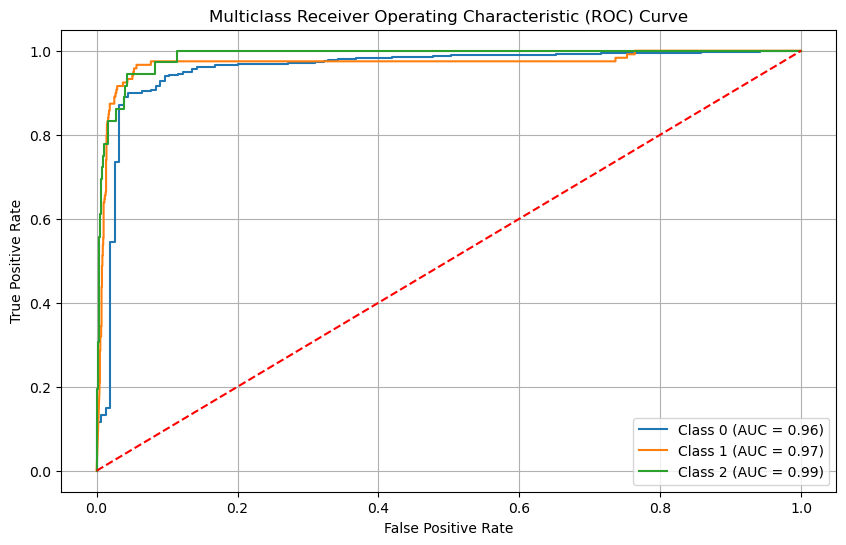

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# multiclassification 
y_test_classes = label_binarize(y_test, classes=[0,1,2])

fpr ={}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_classes[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()